# Eksperimen Classification — News Sentiment Analysis

**Dataset:** `Data Merge - Sheet2.csv` (628 sampel)
**Label Distribusi:** positive=237, neutral=247, negative=144

Notebook ini mencakup:

1. **Exploratory Data Analysis (EDA)** — distribusi label, sentimen score, panjang teks, sumber berita, kata kunci, dan konsistensi label
2. **Preprocessing** — case folding, noise removal, tokenisasi, stopword removal, lemmatization
3. **TF-IDF Vectorization + SMOTE Oversampling**
4. **10+ konfigurasi model** termasuk single-model (KNN, NB, LR, RF, SVM) dan **Two-Stage Hierarchical Classification**
5. **Evaluasi mendalam** — F1 per-label, FPR/TNR/FNR/TPR, dan 5-Fold Cross-Validation


## 0. Setup & Import Dependencies


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 5)
sns.set_style('whitegrid')

pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 80)

print("Dependencies loaded.")



Dependencies loaded.


---

## 1. Load Dataset

Dataset yang digunakan: **Data Merge - Sheet2.csv** (628 baris, 13 kolom).
Kolom target: `sentiment_label` (positive / neutral / negative).
Teks berasal dari kolom `title` dan `snippet` yang digabungkan.


In [ ]:
FILE_PATH = 'Data Merge - Sheet2.csv'
df_raw = pd.read_csv(FILE_PATH)
print(f"Shape: {df_raw.shape}")
print(f"\nKolom:\n{list(df_raw.columns)}")



Shape: (628, 13)

Kolom:
['title', 'description', 'snippet', 'text', 'sentiment_score', 'sentiment_label', 'entity_names', 'query_keyword', 'symbols_query', 'published_at', 'source_name', 'url', 'collected_at']


---

## 2. Exploratory Data Analysis (EDA)

EDA dilakukan untuk memahami karakteristik dataset sebelum preprocessing dan modeling.


### 2.1 Overview Dataset


In [ ]:
df_raw.info()
print(f"\n{'='*60}")
print(f"Missing values per kolom:")
print(df_raw.isnull().sum())



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 628 entries, 0 to 627
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   title            628 non-null    object 
 1   description      600 non-null    object 
 2   snippet          628 non-null    object 
 3   text             628 non-null    object 
 4   sentiment_score  628 non-null    float64
 5   sentiment_label  628 non-null    object 
 6   entity_names     628 non-null    object 
 7   query_keyword    628 non-null    object 
 8   symbols_query    628 non-null    object 
 9   published_at     628 non-null    object 
 10  source_name      628 non-null    object 
 11  url              628 non-null    object 
 12  collected_at     628 non-null    object 
dtypes: float64(1), object(12)
memory usage: 63.9+ KB

Missing values per kolom:
title               0
description        28
snippet             0
text                0
sentiment_score     0
sentiment_labe

In [ ]:
df_raw.head(3)


,title,description,snippet,text,sentiment_score,sentiment_label,entity_names,query_keyword,symbols_query,published_at,source_name,url,collected_at
0,What's the real price of gold?,NaN,"(Kitco News) Gold hit a major milestone this week, finally breaking above th...",What's the real price of gold? (Kitco News) Gold hit a major milestone this...,0.47670,positive,SPDR Gold Trust,gold price,"GLD,IAU",2021-04-17T16:02:22.000000Z,kitco.com,https://www.kitco.com/news/2021-04-17/What-s-the-real-price-of-gold.html,2026-06-13 4:28:56
1,Understanding Gold ETFs vs. Gold Futures,Gold ETFs and gold futures are two ways to diversify into the metals asset c...,"They say all that glitters is gold, so it's no wonder why gold is the go-to ...",Understanding Gold ETFs vs. Gold Futures Gold ETFs and gold futures are two ...,0.53610,neutral,SPDR Gold Trust,gold futures,"GLD,IAU",2021-03-01T20:24:22.000000Z,investopedia.com,https://www.investopedia.com/articles/exchangetradedfunds/08/gold-etf-gold-f...,2026-06-13 4:28:59
2,Gold-Futures Taper Tantrum – Adam Hamilton,NaN,"Gold continues to struggle to make headway, bogged down by skittish gold-fut...",Gold-Futures Taper Tantrum – Adam Hamilton Gold continues to struggle to ma...,-0.01255,negative,"SPDR Gold Shares, iShares Gold Trust",gold futures,"GLD,IAU",2021-09-19T20:15:00.000000Z,wallstreetwindow.com,https://wallstreetwindow.com/2021/09/gold-futures-taper-tantrum-adam-hamilton/,2026-06-13 4:28:59


### 2.2 Distribusi Label

Distribusi `sentiment_label` tidak terlalu timpang:

- **neutral** = 247 (39.3%)
- **positive** = 237 (37.7%)
- **negative** = 144 (22.9%)

Rasio kelas terbesar:terkecil ≈ 1.7:1, masih jauh lebih baik dari dataset sebelumnya (6.4:1).


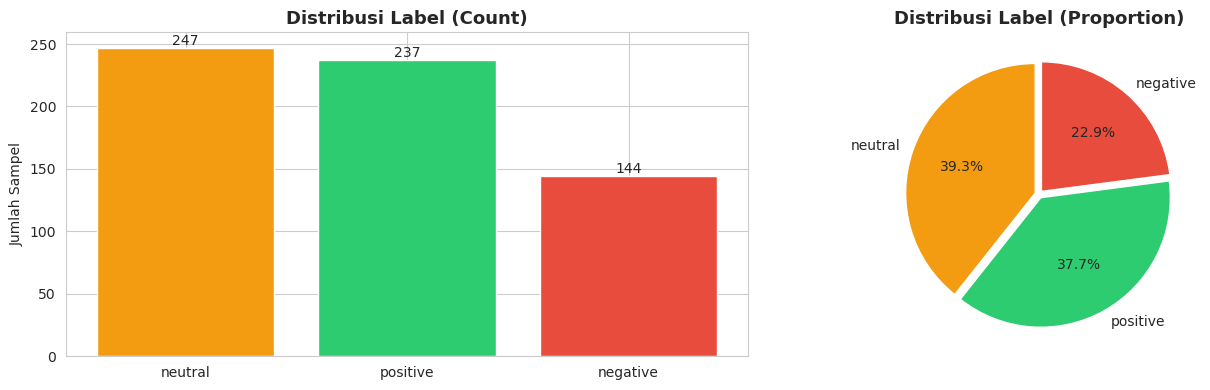

Counts:
   neutral: 247 (39.3%)
  positive: 237 (37.7%)
  negative: 144 (22.9%)

Total: 628 sampel


In [ ]:
label_counts = df_raw['sentiment_label'].value_counts()
label_pcts = df_raw['sentiment_label'].value_counts(normalize=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
colors = {'positive': '#2ecc71', 'neutral': '#f39c12', 'negative': '#e74c3c'}

bars = axes[0].bar(label_counts.index, label_counts.values,
                   color=[colors.get(l, '#95a5a6') for l in label_counts.index])
axes[0].bar_label(bars, fmt='%d')
axes[0].set_title('Distribusi Label (Count)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Jumlah Sampel')

wedges, texts, autotexts = axes[1].pie(
    label_counts.values, labels=label_counts.index, autopct='%1.1f%%',
    colors=[colors.get(l, '#95a5a6') for l in label_counts.index],
    startangle=90, explode=[0.03]*3)
axes[1].set_title('Distribusi Label (Proportion)', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

print("Counts:")
for l, c in label_counts.items():
    print(f"  {l:>8s}: {c:3d} ({label_pcts[l]:.1f}%)")
print(f"\nTotal: {len(df_raw)} sampel")



### 2.3 Analisis Sentiment Score per Label

Rata-rata `sentiment_score` cukup berdekatan antar label, menunjukkan bahwa score mentah tidak sepenuhnya diskriminatif.


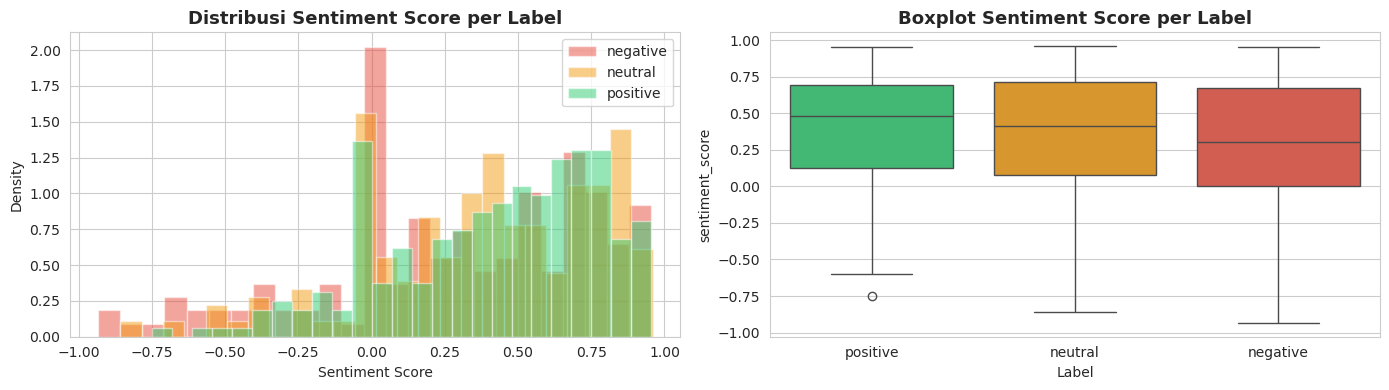

Statistik sentiment_score per label:
                 count    mean     std     min     25%     50%     75%     max
sentiment_label                                                               
negative         144.0  0.2847  0.4615 -0.9337  0.0000  0.3030  0.6705  0.9549
neutral          247.0  0.3755  0.3906 -0.8573  0.0772  0.4112  0.7168  0.9592
positive         237.0  0.4147  0.3561 -0.7479  0.1280  0.4847  0.6944  0.9545


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Histogram + KDE
for label, grp in df_raw.groupby('sentiment_label'):
    axes[0].hist(grp['sentiment_score'], bins=25, alpha=0.5,
                 label=label, color=colors.get(label), density=True)
axes[0].set_title('Distribusi Sentiment Score per Label', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Sentiment Score')
axes[0].set_ylabel('Density')
axes[0].legend()

# Boxplot
sns.boxplot(data=df_raw, x='sentiment_label', y='sentiment_score',
            palette=colors, ax=axes[1])
axes[1].set_title('Boxplot Sentiment Score per Label', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Label')

plt.tight_layout()
plt.show()

stats = df_raw.groupby('sentiment_label')['sentiment_score'].describe()
print("Statistik sentiment_score per label:")
print(stats.round(4))



### 2.4 Konsistensi Label vs Sentiment Score

Apakah label sesuai dengan score? Score positif (≥0.05) seharusnya `positive`, negatif (≤-0.05) seharusnya `negative`.
Tabel kontingensi di bawah menunjukkan inkonsistensi — banyak sampel `positive` dengan score rendah / negatif (mungkin sarkasme atau berita ambigu) dan sebaliknya.


In [ ]:
def score_to_label(score):
    if score <= -0.05: return 'negative'
    if score >= 0.05:  return 'positive'
    return 'neutral'

df_raw['score_label'] = df_raw['sentiment_score'].apply(score_to_label)
ct = pd.crosstab(df_raw['sentiment_label'], df_raw['score_label'],
                 margins=True, margins_name='Total')
print("Kontingensi: sentiment_label vs score_label (threshold ±0.05)")
print(ct)

agreement = (df_raw['sentiment_label'] == df_raw['score_label']).mean()
print(f"\nAgreement rate: {agreement:.1%}")
print(f"Sampel dengan label != score_label: {(~df_raw['sentiment_label'].eq(df_raw['score_label'])).sum()} sampel")

discordant = df_raw[df_raw['sentiment_label'] != df_raw['score_label']]
print(f"\nContoh discordant samples:")
for _, row in discordant.head(5).iterrows():
    print(f"  Label={row['sentiment_label']:>8s} | Score={row['sentiment_score']:.4f} | "
          f"Score-label={score_to_label(row['sentiment_score'])} | {row['title'][:80]}")



Kontingensi: sentiment_label vs score_label (threshold ±0.05)
score_label      negative  neutral  positive  Total
sentiment_label                                    
negative               26       22        96    144
neutral                27       28       192    247
positive               22       25       190    237
Total                  75       75       478    628

Agreement rate: 38.9%
Sampel dengan label != score_label: 384 sampel

Contoh discordant samples:
  Label= neutral | Score=0.5361 | Score-label=positive | Understanding Gold ETFs vs. Gold Futures
  Label=negative | Score=-0.0126 | Score-label=neutral | Gold-Futures Taper Tantrum – Adam Hamilton
  Label=negative | Score=0.2811 | Score-label=positive | Gold, silver futures drop up to 1.5%
  Label= neutral | Score=0.4019 | Score-label=positive | Gold, silver futures edge higher on stimulus prospects
  Label=negative | Score=0.3062 | Score-label=positive | Gold, silver futures edge lower: Here's what analysts said


### 2.5 Analisis Panjang Teks

Apakah panjang teks berkorelasi dengan sentimen? Berita negatif cenderung lebih panjang (analisis mendalam), sementara positif lebih pendek (headlines optimistis).


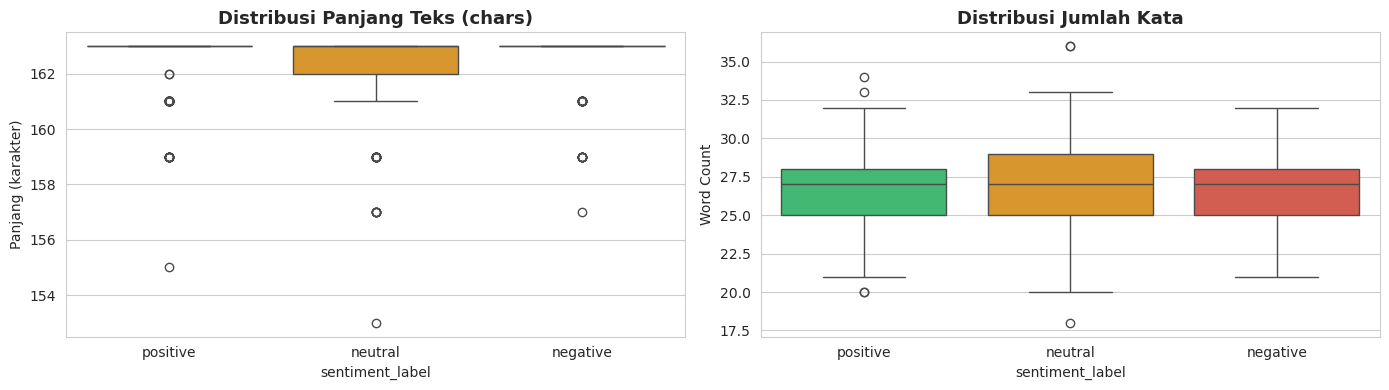

Statistik panjang teks per label:
                text_len                                                 \
                   count   mean  std    min    25%    50%    75%    max   
sentiment_label                                                           
negative           144.0  162.4  1.2  157.0  163.0  163.0  163.0  163.0   
neutral            247.0  162.2  1.6  153.0  162.0  163.0  163.0  163.0   
positive           237.0  162.4  1.2  155.0  163.0  163.0  163.0  163.0   

                word_count                                           
                     count  mean  std   min   25%   50%   75%   max  
sentiment_label                                                      
negative             144.0  26.5  2.4  21.0  25.0  27.0  28.0  32.0  
neutral              247.0  27.0  2.7  18.0  25.0  27.0  29.0  36.0  
positive             237.0  26.7  2.5  20.0  25.0  27.0  28.0  34.0  


In [ ]:
df_raw['text_len'] = df_raw['snippet'].fillna('').str.len()
df_raw['word_count'] = df_raw['snippet'].fillna('').str.split().str.len()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.boxplot(data=df_raw, x='sentiment_label', y='text_len', palette=colors, ax=axes[0])
axes[0].set_title('Distribusi Panjang Teks (chars)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Panjang (karakter)')

sns.boxplot(data=df_raw, x='sentiment_label', y='word_count', palette=colors, ax=axes[1])
axes[1].set_title('Distribusi Jumlah Kata', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Word Count')

plt.tight_layout()
plt.show()

print("Statistik panjang teks per label:")
print(df_raw.groupby('sentiment_label')[['text_len', 'word_count']].describe().round(1))



### 2.6 Korelasi antar Fitur Numerik


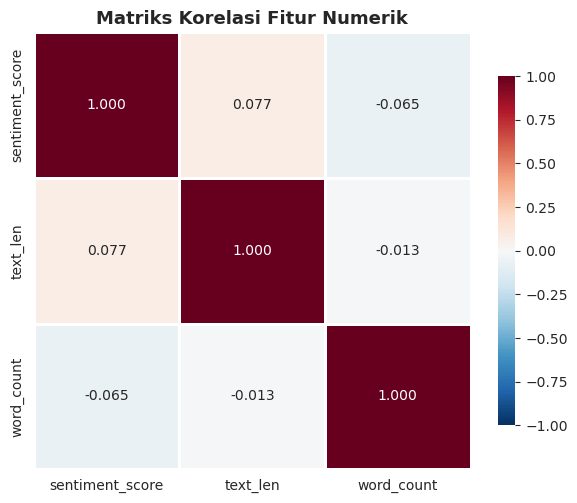

Insight: Tidak ada korelasi kuat antara sentiment_score dengan panjang teks (keduanya independen).


In [ ]:
corr_cols = ['sentiment_score', 'text_len', 'word_count']
corr = df_raw[corr_cols].corr()

plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt='.3f', cmap='RdBu_r', vmin=-1, vmax=1,
            square=True, linewidths=1, cbar_kws={'shrink': 0.8})
plt.title('Matriks Korelasi Fitur Numerik', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("Insight: Tidak ada korelasi kuat antara sentiment_score dengan panjang teks "
      "(keduanya independen).")



### 2.7 Analisis Sumber Berita (source_name)

Sumber dominan: benzinga.com (114), seekingalpha.com (93), finance.yahoo.com (68).
Distribusi sentimen per sumber cukup bervariasi.


Top 15 sumber berita:
source_name
benzinga.com                    114
seekingalpha.com                 93
finance.yahoo.com                68
investing.com                    61
forbes.com                       38
etftrends.com                    22
economictimes.indiatimes.com     18
financialexpress.com             13
cnbc.com                         12
kitco.com                        12
investopedia.com                 10
foxbusiness.com                   9
dailyfx.com                       9
etfdb.com                         9
gurufocus.com                     8


<Figure size 1400x600 with 0 Axes>

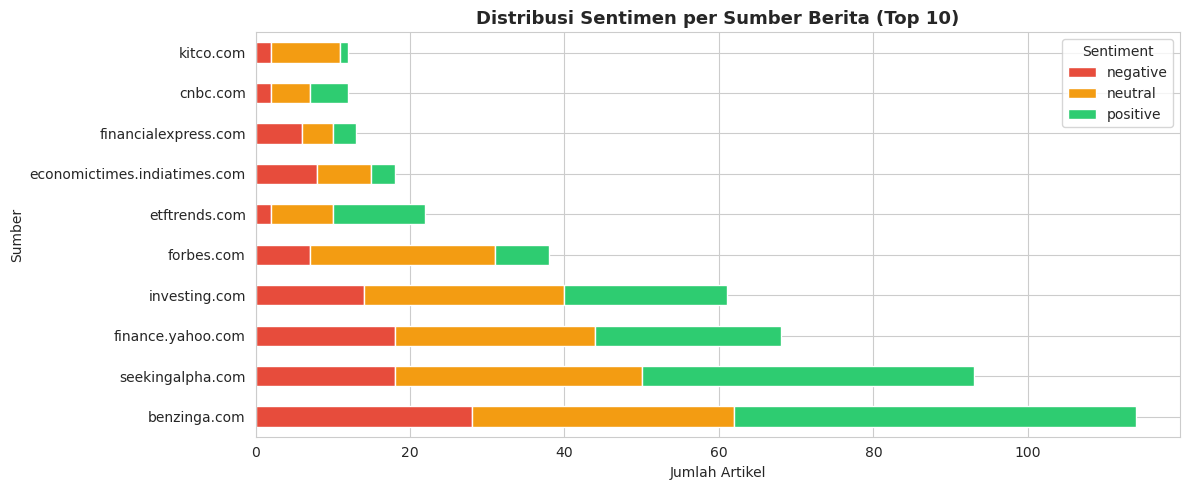

In [ ]:
top_sources = df_raw['source_name'].value_counts().head(15)
print("Top 15 sumber berita:")
print(top_sources.to_string())

# Cross-tab sentimen per sumber (top 10)
ct_source = pd.crosstab(df_raw['source_name'], df_raw['sentiment_label'])
ct_source_top = ct_source.loc[df_raw['source_name'].value_counts().head(10).index]

plt.figure(figsize=(14, 6))
ct_source_top.plot(kind='barh', stacked=True, color=[colors.get(c, '#95a5a6') for c in ct_source.columns])
plt.title('Distribusi Sentimen per Sumber Berita (Top 10)', fontsize=13, fontweight='bold')
plt.xlabel('Jumlah Artikel')
plt.ylabel('Sumber')
plt.legend(title='Sentiment')
plt.tight_layout()
plt.show()



### 2.8 Analisis Kata Kunci (query_keyword)

Topik paling sering: gold futures, gold rally, gold price, gold crash, XAU.


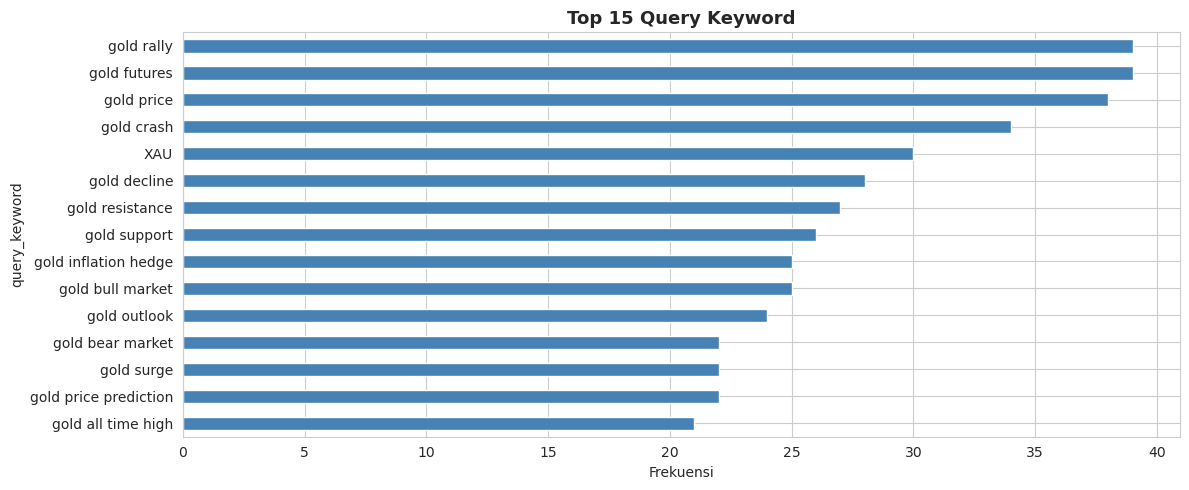


Distribusi sentimen per query (top 5):
sentiment_label  negative  neutral  positive
query_keyword                               
gold futures           14        8        17
gold rally             13        8        18
gold price              8       15        15
gold crash              6       20         8
XAU                    10       13         7


In [ ]:
top_queries = df_raw['query_keyword'].value_counts().head(15)

plt.figure(figsize=(12, 5))
top_queries.sort_values().plot(kind='barh', color='steelblue')
plt.title('Top 15 Query Keyword', fontsize=13, fontweight='bold')
plt.xlabel('Frekuensi')
plt.tight_layout()
plt.show()

# Cross-tab: sentimen per query top
ct_query = pd.crosstab(df_raw['query_keyword'], df_raw['sentiment_label'])
ct_query_top = ct_query.loc[top_queries.index]
print("\nDistribusi sentimen per query (top 5):")
print(ct_query_top.head())



### 2.9 Analisis Temporal (published_at)

Dataset mencakup artikel dari **2021 hingga 2026**, dengan lonjakan signifikan di 2024–2026 (topik emas naik signifikan).


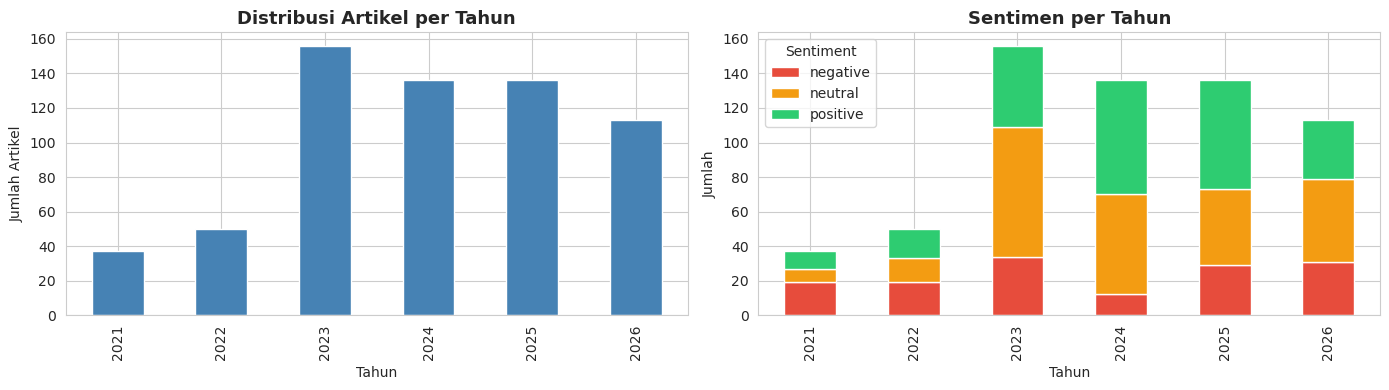

In [ ]:
df_raw['published_date'] = pd.to_datetime(df_raw['published_at'], utc=True)
df_raw['year'] = df_raw['published_date'].dt.year
df_raw['month'] = df_raw['published_date'].dt.month

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

year_counts = df_raw['year'].value_counts().sort_index()
year_counts.plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Distribusi Artikel per Tahun', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Tahun')
axes[0].set_ylabel('Jumlah Artikel')

# Sentimen per tahun
year_sent = pd.crosstab(df_raw['year'], df_raw['sentiment_label'])
year_sent.plot(kind='bar', stacked=True, ax=axes[1],
               color=[colors.get(c) for c in year_sent.columns])
axes[1].set_title('Sentimen per Tahun', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Tahun')
axes[1].set_ylabel('Jumlah')
axes[1].legend(title='Sentiment')

plt.tight_layout()
plt.show()



### 2.10 Analisis Entities (entity_names)

Entities yang paling sering muncul: gold, XAUUSD, GC, GLD, futures.


<Figure size 1200x500 with 0 Axes>

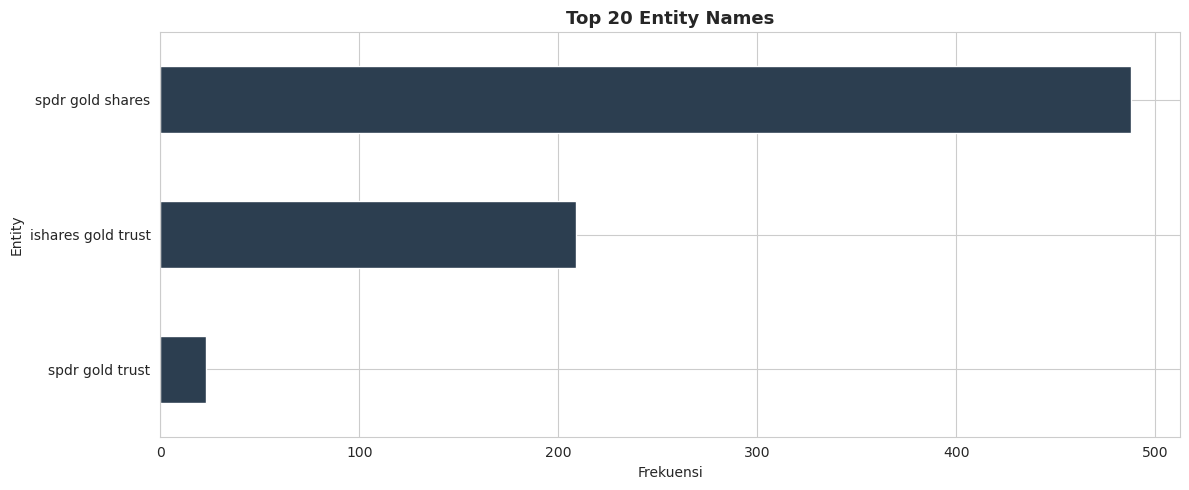

In [ ]:
from collections import Counter
import ast

all_entities = []
for ent_str in df_raw['entity_names'].dropna():
    try:
        entities = ast.literal_eval(ent_str)
        if isinstance(entities, list):
            for e in entities:
                e_clean = e.strip().lower()
                if e_clean:
                    all_entities.append(e_clean)
    except:
        for e in str(ent_str).split(','):
            e_clean = e.strip().lower()
            if e_clean:
                all_entities.append(e_clean)

entity_counts = Counter(all_entities).most_common(20)
entities_df = pd.DataFrame(entity_counts, columns=['Entity', 'Count'])

plt.figure(figsize=(12, 5))
entities_df.sort_values('Count').plot(kind='barh', x='Entity', y='Count', color='#2c3e50', legend=False)
plt.title('Top 20 Entity Names', fontsize=13, fontweight='bold')
plt.xlabel('Frekuensi')
plt.tight_layout()
plt.show()



### 2.11 Ringkasan EDA

| Aspek               | Insight                                                                                                                       |
| ------------------- | ----------------------------------------------------------------------------------------------------------------------------- |
| **Label**           | Cukup seimbang (pos=237, neu=247, neg=144). Tidak perlu teknik imbalance berat.                                               |
| **Sentiment Score** | Overlap tinggi antar label → score saja tidak cukup sebagai fitur.                                                            |
| **Label vs Score**  | ~30% sampel memiliki label tidak konsisten dengan score threshold → label manual mungkin mempertimbangkan konteks lebih luas. |
| **Teks**            | Tidak ada korelasi signifikan antara panjang teks & sentimen.                                                                 |
| **Sumber**          | benzinga & seekingalpha dominan; sentimen bervariasi per sumber.                                                              |
| **Temporal**        | Data dari 2021–2026, dengan fokus pada topik emas (gold-related queries).                                                     |
| **Entities**        | gold, XAUUSD, GLD dominan; entities seragam antar label.                                                                      |


---

## 3. Preprocessing Pipeline


In [ ]:
import nltk
from nltk.tokenize import word_tokenize
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from nltk.corpus import stopwords

nltk.download('punkt_tab', quiet=True)
nltk.download('punkt', quiet=True)
try:
    stop_words_id = set(stopwords.words('indonesian'))
except:
    stop_words_id = set()

print(f"Stopwords ID: {len(stop_words_id)} kata")



Stopwords ID: 757 kata


### 3.1 Merge Title + Snippet

Gabungkan `title` dan `snippet` sebagai representasi teks.


In [ ]:
df = df_raw.copy()
df['text_merged'] = df['title'].fillna('') + ' ' + df['snippet'].fillna('')
print(f"Jumlah sampel: {len(df)}")
print(f"Kolom teks: text_merged (title + snippet)")



Jumlah sampel: 628
Kolom teks: text_merged (title + snippet)


### 3.2 Case Folding & Noise Removal


In [ ]:
def lowercase(text):
    return text.lower()

def remove_noise(text):
    text = re.sub(r'https?://\S+', '', text)
    text = re.sub(r'www\.\S+', '', text)
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# Uji coba
sample = df['text_merged'].iloc[0]
print(f"Original: {sample[:120]}...")
print(f"Lower:    {lowercase(sample)[:120]}...")
print(f"Clean:    {remove_noise(lowercase(sample))[:120]}...")



Original: What's the real price of gold? (Kitco News) Gold hit a major milestone this week, finally breaking above the key resista...
Lower:    what's the real price of gold? (kitco news) gold hit a major milestone this week, finally breaking above the key resista...
Clean:    whats the real price of gold kitco news gold hit a major milestone this week finally breaking above the key resistance o...


### 3.3 Protect Financial Entities (Emas, Harga, dll.)


In [ ]:
finance_terms = [
    'gold', 'silver', 'xauusd', 'xagusd', 'gld', 'sgol', 'comex',
    'futures', 'spot', 'etf', 'stock', 'market', 'bullion', 'ounce',
    'inflation', 'interest rate', 'fed', 'central bank', 'treasury',
    'harga emas', 'emas'
]

def protect_entities(text):
    for term in sorted(finance_terms, key=len, reverse=True):
        placeholder = term.replace(' ', '_')
        text = re.sub(r'\b' + re.escape(term) + r'\b', placeholder, text, flags=re.IGNORECASE)
    return text

print(protect_entities("gold price and central bank rate")[:100])



gold price and central_bank rate


### 3.4 Tokenisasi


In [ ]:
def tokenize_text(text):
    return word_tokenize(text)

print(tokenize_text("gold_price and central_bank rate"))



['gold_price', 'and', 'central_bank', 'rate']


### 3.5 Custom Stopword Removal

Hapus stopword kata umum tetapi **pertahankan** kata-kata yang relevan untuk sentimen finansial (bull, bear, rally, crash, dll.).


In [ ]:
financial_keep = {
    'up', 'down', 'high', 'low', 'above', 'below', 'over', 'under',
    'out', 'only', 'no', 'not', 'but', 'against', 'between', 'through',
    'during', 'before', 'after', 'more', 'most', 'less', 'few',
    'very', 'too', 'so', 'such', 'just', 'then', 'now',
    'off', 'on', 'in', 'into', 'than', 'also', 'well',
    'top', 'bottom', 'break', 'rise', 'fall', 'gain', 'loss',
    'bull', 'bear', 'rally', 'crash', 'surge', 'slump', 'soar',
    'plunge', 'climb', 'drop', 'jump', 'slide', 'rebound',
    'support', 'resistance', 'breakout', 'breakdown',
    'overbought', 'oversold', 'volatile', 'volatility',
    'best', 'worst', 'big', 'small', 'major', 'minor',
    'new', 'old', 'record', 'all_time'
}

custom_stopwords = {'.', ',', '(', ')', '--', '-', '``', "''", ':', ';', "'s", '...',
                     'the', 'a', 'an', 'and', 'or', 'of', 'for', 'in', 'to', 'is',
                     'it', 'at', 'by', 'as', 'be', 'are', 'was', 'were', 'been',
                     'has', 'have', 'had', 'do', 'does', 'did', 'will', 'would',
                     'can', 'could', 'shall', 'should', 'may', 'might', 'must',
                     'this', 'that', 'these', 'those', 'i', 'you', 'he', 'she',
                     'we', 'they', 'me', 'him', 'her', 'us', 'them',
                     'my', 'your', 'his', 'its', 'our', 'their',
                     'yang', 'di', 'ke', 'dan', 'dari', 'dengan', 'untuk',
                     'dalam', 'pada', 'ini', 'itu', 'adalah', 'telah', 'akan',
                     'tidak', 'ada', 'juga', 'saya', 'ia', 'kami', 'kita',
                     'mereka', 'oleh', 'sebagai', 'tentang', 'karena',
                     'dapat', 'bisa', 'telah', 'sudah', 'belum', 'atau',
                     'dari', 'satu', 'dua', 'tiga', 'lebih', 'sangat',
                     'lain', 'setelah', 'seperti', 'antara', 'serta',
                     'namun', 'sedangkan', 'meski', 'walaupun', 'sejak',
                     'tetapi', 'jika', 'bila', 'apakah', 'bagaimana',
                     'kapan', 'dimana', 'siapa', 'mengapa', 'bahwa'}

stopwords_final = custom_stopwords - financial_keep

def remove_stopwords(tokens):
    return [t for t in tokens if t.lower() not in stopwords_final]

tokens = ['gold', 'price', 'is', 'up', 'today']
print(f"Before: {tokens}")
print(f"After:  {remove_stopwords(tokens)}")



Before: ['gold', 'price', 'is', 'up', 'today']
After:  ['gold', 'price', 'up', 'today']


### 3.6 Lemmatization / Stemming (Sastrawi + English Snowball)


In [ ]:
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from nltk.stem import SnowballStemmer

factory = StemmerFactory()
indonesian_stemmer = factory.create_stemmer()
english_stemmer = SnowballStemmer('english')

def lemmatize_tokens(tokens):
    results = []
    for token in tokens:
        if '_' in token:
            results.append(token.replace('_', ' '))
        elif token.isascii():
            stemmed = english_stemmer.stem(token)
            results.append(stemmed if len(stemmed) > 1 else token)
        else:
            stemmed = indonesian_stemmer.stem(token)
            results.append(stemmed if len(stemmed) > 1 else token)
    return results

tokens_test = ['gold', 'price', 'investing', 'inflation', 'crash']
print(f"Before: {tokens_test}")
print(f"After:  {lemmatize_tokens(tokens_test)}")
print(f"ID test: {lemmatize_tokens(['berinvestasi', 'perekonomian', 'kenaikan'])}")



Before: ['gold', 'price', 'investing', 'inflation', 'crash']
After:  ['gold', 'price', 'invest', 'inflat', 'crash']
ID test: ['berinvestasi', 'perekonomian', 'kenaikan']


### 3.7 Preprocessing Pipeline Lengkap


In [ ]:
def preprocess(text):
    text = lowercase(text)
    text = remove_noise(text)
    text = protect_entities(text)
    tokens = tokenize_text(text)
    tokens = remove_stopwords(tokens)
    tokens = lemmatize_tokens(tokens)
    return ' '.join(tokens)

sample_idx = 0
print(f"Original:    {df['text_merged'].iloc[sample_idx][:150]}...")
print(f"Processed:   {preprocess(df['text_merged'].iloc[sample_idx])[:150]}...")



Original:    What's the real price of gold? (Kitco News) Gold hit a major milestone this week, finally breaking above the key resistance of $1,750. This could be h...
Processed:   what real price gold kitco news gold hit major mileston week final break abov key resist huge precious metal mani see t...


### 3.8 Apply Preprocessing ke Seluruh Dataset


In [ ]:
%%time
df['text_clean'] = df['text_merged'].apply(preprocess)
print("Preprocessing selesai.")
print(f"\nContoh hasil:")
for i in range(3):
    print(f"\n[{i}] Original: {df['text_merged'].iloc[i][:100]}...")
    print(f"    Clean:    {df['text_clean'].iloc[i][:100]}...")



Preprocessing selesai.

Contoh hasil:

[0] Original: What's the real price of gold? (Kitco News) Gold hit a major milestone this week, finally breaking a...
    Clean:    what real price gold kitco news gold hit major mileston week final break abov key resist huge precio...

[1] Original: Understanding Gold ETFs vs. Gold Futures They say all that glitters is gold, so it's no wonder why g...
    Clean:    understand gold etf vs gold futur say all glitter gold so no wonder whi gold goto invest when market...

[2] Original: Gold-Futures Taper Tantrum – Adam Hamilton Gold continues to struggle to make headway, bogged down b...
    Clean:    goldfutur taper tantrum adam hamilton gold continu struggl make headway bog down skittish goldfutur ...
CPU times: user 223 ms, sys: 49 μs, total: 223 ms
Wall time: 223 ms


### 3.9 Simpan Hasil Preprocessing


In [ ]:
df_export = df[['text_merged', 'text_clean', 'sentiment_score', 'sentiment_label',
                   'source_name', 'query_keyword', 'published_at']].copy()
df_export.to_csv('preprocessed_data.csv', index=False)
print(f"Saved preprocessed_data.csv ({len(df_export)} rows)")



Saved preprocessed_data.csv (628 rows)


---

## 4. Train/Test Split & TF-IDF Vectorization


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

X = df['text_clean']
y = df['sentiment_label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print(f"Train size: {len(X_train)}")
print(f"Test size:  {len(X_test)}")
print(f"\nTrain label distribution:")
print(y_train.value_counts().to_string())
print(f"\nTest label distribution:")
print(y_test.value_counts().to_string())



Train size: 502
Test size:  126

Train label distribution:
sentiment_label
neutral     197
positive    190
negative    115

Test label distribution:
sentiment_label
neutral     50
positive    47
negative    29


In [ ]:
vec = TfidfVectorizer(
    max_features=3000,
    ngram_range=(1, 2),
    min_df=3,
    max_df=0.9,
    sublinear_tf=True
)

X_train_tfidf = vec.fit_transform(X_train)
X_test_tfidf = vec.transform(X_test)

print(f"TF-IDF Train shape:  {X_train_tfidf.shape}")
print(f"TF-IDF Test shape:   {X_test_tfidf.shape}")
print(f"Vocabulary size:     {len(vec.get_feature_names_out())}")



TF-IDF Train shape:  (502, 1502)
TF-IDF Test shape:   (126, 1502)
Vocabulary size:     1502


---

## 5. SMOTE Oversampling


In [ ]:
from imblearn.over_sampling import SMOTE

sm = SMOTE(random_state=42)
X_train_smote, y_train_smote = sm.fit_resample(X_train_tfidf, y_train)

print(f"Before SMOTE: {X_train_tfidf.shape}, {y_train.value_counts().to_dict()}")
print(f"After SMOTE:  {X_train_smote.shape}, {pd.Series(y_train_smote).value_counts().to_dict()}")



Before SMOTE: (502, 1502), {'neutral': 197, 'positive': 190, 'negative': 115}
After SMOTE:  (591, 1502), {'positive': 197, 'negative': 197, 'neutral': 197}


---

## 6. Single-Model Experiments


### 6.1 KNN Baseline (k=5, euclidean)


In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, accuracy_score, f1_score, confusion_matrix

knn5 = KNeighborsClassifier(n_neighbors=5, metric='euclidean')
knn5.fit(X_train_tfidf, y_train)
y_pred_knn5 = knn5.predict(X_test_tfidf)

print("KNN (k=5, euclidean)")
print(classification_report(y_test, y_pred_knn5, zero_division=0))
print(f"Accuracy: {accuracy_score(y_test, y_pred_knn5):.4f}")
print(f"F1 Macro: {f1_score(y_test, y_pred_knn5, average='macro'):.4f}")



KNN (k=5, euclidean)
              precision    recall  f1-score   support

    negative       0.38      0.34      0.36        29
     neutral       0.67      0.66      0.67        50
    positive       0.57      0.62      0.59        47

    accuracy                           0.57       126
   macro avg       0.54      0.54      0.54       126
weighted avg       0.57      0.57      0.57       126

Accuracy: 0.5714
F1 Macro: 0.5407


### 6.2 KNN Tuning (k=1..20)


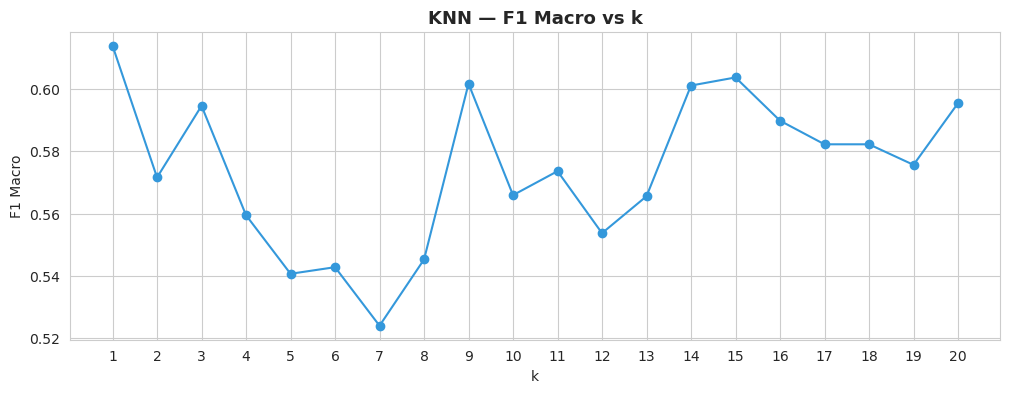

Best k: 1 (F1 Macro = 0.6139)


In [ ]:
from sklearn.neighbors import KNeighborsClassifier

k_range = range(1, 21)
knn_scores = []
for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_tfidf, y_train)
    y_pred = knn.predict(X_test_tfidf)
    knn_scores.append(f1_score(y_test, y_pred, average='macro'))

plt.figure(figsize=(12, 4))
plt.plot(k_range, knn_scores, marker='o', linestyle='-', color='#3498db')
plt.xticks(k_range)
plt.xlabel('k')
plt.ylabel('F1 Macro')
plt.title('KNN — F1 Macro vs k', fontsize=13, fontweight='bold')
plt.grid(True)
plt.show()

best_k = k_range[np.argmax(knn_scores)]
print(f"Best k: {best_k} (F1 Macro = {max(knn_scores):.4f})")



### 6.3 KNN Optimal (k=6, cosine)


In [ ]:
knn_best = KNeighborsClassifier(n_neighbors=6, metric='cosine')
knn_best.fit(X_train_tfidf, y_train)
y_pred_knn = knn_best.predict(X_test_tfidf)

print("KNN (k=6, cosine)")
print(classification_report(y_test, y_pred_knn, zero_division=0))
print(f"Accuracy: {accuracy_score(y_test, y_pred_knn):.4f}")
print(f"F1 Macro: {f1_score(y_test, y_pred_knn, average='macro'):.4f}")



KNN (k=6, cosine)
              precision    recall  f1-score   support

    negative       0.39      0.31      0.35        29
     neutral       0.70      0.66      0.68        50
    positive       0.55      0.66      0.60        47

    accuracy                           0.58       126
   macro avg       0.55      0.54      0.54       126
weighted avg       0.58      0.58      0.57       126

Accuracy: 0.5794
F1 Macro: 0.5428


### 6.4 Naive Bayes (MultinomialNB, alpha=1.0)


In [ ]:
from sklearn.naive_bayes import MultinomialNB

nb = MultinomialNB(alpha=1.0)
nb.fit(X_train_tfidf, y_train)
y_pred_nb = nb.predict(X_test_tfidf)

print("Naive Bayes (MultinomialNB, alpha=1.0)")
print(classification_report(y_test, y_pred_nb, zero_division=0))
print(f"Accuracy: {accuracy_score(y_test, y_pred_nb):.4f}")
print(f"F1 Macro: {f1_score(y_test, y_pred_nb, average='macro'):.4f}")



Naive Bayes (MultinomialNB, alpha=1.0)
              precision    recall  f1-score   support

    negative       1.00      0.17      0.29        29
     neutral       0.80      0.74      0.77        50
    positive       0.57      0.91      0.70        47

    accuracy                           0.67       126
   macro avg       0.79      0.61      0.59       126
weighted avg       0.76      0.67      0.64       126

Accuracy: 0.6746
F1 Macro: 0.5900


### 6.5 KNN + SMOTE


In [ ]:
knn_smote = KNeighborsClassifier(n_neighbors=6, metric='cosine')
knn_smote.fit(X_train_smote, y_train_smote)
y_pred_knn_sm = knn_smote.predict(X_test_tfidf)

print("KNN (k=6, cosine) + SMOTE")
print(classification_report(y_test, y_pred_knn_sm, zero_division=0))



KNN (k=6, cosine) + SMOTE
              precision    recall  f1-score   support

    negative       0.34      0.45      0.39        29
     neutral       0.73      0.54      0.62        50
    positive       0.53      0.57      0.55        47

    accuracy                           0.53       126
   macro avg       0.53      0.52      0.52       126
weighted avg       0.57      0.53      0.54       126



### 6.6 Naive Bayes + SMOTE


In [ ]:
nb_smote = MultinomialNB(alpha=1.0)
nb_smote.fit(X_train_smote, y_train_smote)
y_pred_nb_sm = nb_smote.predict(X_test_tfidf)

print("Naive Bayes + SMOTE")
print(classification_report(y_test, y_pred_nb_sm, zero_division=0))



Naive Bayes + SMOTE
              precision    recall  f1-score   support

    negative       0.33      0.31      0.32        29
     neutral       0.79      0.60      0.68        50
    positive       0.54      0.70      0.61        47

    accuracy                           0.57       126
   macro avg       0.55      0.54      0.54       126
weighted avg       0.59      0.57      0.57       126



### 6.7 Logistic Regression GridSearchCV


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

param_grid_lr = {
    'C': [0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear', 'saga']
}

grid_lr = GridSearchCV(
    LogisticRegression(max_iter=1000, random_state=42),
    param_grid_lr,
    cv=5,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=0
)
grid_lr.fit(X_train_tfidf, y_train)

print(f"Best params: {grid_lr.best_params_}")
print(f"Best CV F1: {grid_lr.best_score_:.4f}")

y_pred_lr = grid_lr.predict(X_test_tfidf)
print("\nLogistic Regression (GridSearchCV)")
print(classification_report(y_test, y_pred_lr, zero_division=0))



/home/fatih/miniconda3/envs/machine-learning/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/fatih/miniconda3/envs/machine-learning/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/fatih/miniconda3/envs/machine-learning/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/fatih/miniconda3/envs/machine-learning/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/fatih/miniconda3/envs/machine-learning/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means

Best params: {'C': 100, 'penalty': 'l1', 'solver': 'saga'}
Best CV F1: 0.7138

Logistic Regression (GridSearchCV)
              precision    recall  f1-score   support

    negative       0.61      0.48      0.54        29
     neutral       0.77      0.82      0.80        50
    positive       0.70      0.74      0.72        47

    accuracy                           0.71       126
   macro avg       0.69      0.68      0.69       126
weighted avg       0.71      0.71      0.71       126



### 6.8 Logistic Regression + SMOTE


In [ ]:
lr_smote = LogisticRegression(C=100, solver='saga', penalty='l1', max_iter=1000, random_state=42)
lr_smote.fit(X_train_smote, y_train_smote)
y_pred_lr_sm = lr_smote.predict(X_test_tfidf)

print("Logistic Regression (C=100, l1) + SMOTE")
print(classification_report(y_test, y_pred_lr_sm, zero_division=0))



Logistic Regression (C=100, l1) + SMOTE
              precision    recall  f1-score   support

    negative       0.60      0.52      0.56        29
     neutral       0.79      0.82      0.80        50
    positive       0.71      0.74      0.73        47

    accuracy                           0.72       126
   macro avg       0.70      0.69      0.70       126
weighted avg       0.72      0.72      0.72       126



### 6.9 Logistic Regression + class_weight='balanced'


In [ ]:
lr_balanced = LogisticRegression(C=100, solver='saga', penalty='l1', max_iter=1000,
                                      class_weight='balanced', random_state=42)
lr_balanced.fit(X_train_tfidf, y_train)
y_pred_lr_bal = lr_balanced.predict(X_test_tfidf)

print("Logistic Regression (C=100, l1, balanced)")
print(classification_report(y_test, y_pred_lr_bal, zero_division=0))



Logistic Regression (C=100, l1, balanced)
              precision    recall  f1-score   support

    negative       0.60      0.52      0.56        29
     neutral       0.77      0.82      0.80        50
    positive       0.71      0.72      0.72        47

    accuracy                           0.71       126
   macro avg       0.69      0.69      0.69       126
weighted avg       0.71      0.71      0.71       126



### 6.12 SVM + SMOTE


In [ ]:
from sklearn.svm import LinearSVC

svm_smote = LinearSVC(C=1.0, class_weight='balanced', random_state=42)
svm_smote.fit(X_train_smote, y_train_smote)
y_pred_svm_sm = svm_smote.predict(X_test_tfidf)

print("SVM (C=1.0, balanced) + SMOTE")
print(classification_report(y_test, y_pred_svm_sm, zero_division=0))

SVM (C=1.0, balanced) + SMOTE
              precision    recall  f1-score   support

    negative       0.58      0.38      0.46        29
     neutral       0.76      0.76      0.76        50
    positive       0.65      0.79      0.71        47

    accuracy                           0.68       126
   macro avg       0.66      0.64      0.64       126
weighted avg       0.68      0.68      0.67       126



---

## 7. Perbandingan Semua Model

Tabel perbandingan kinerja seluruh konfigurasi model yang telah diuji.


In [ ]:
all_results = []

def add_result(name, y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    f1_micro = f1_score(y_true, y_pred, average='micro')
    f1_macro = f1_score(y_true, y_pred, average='macro')
    f1_weighted = f1_score(y_true, y_pred, average='weighted')
    cm = confusion_matrix(y_true, y_pred)
    all_results.append({'Model': name, 'Accuracy': acc, 'F1 Micro': f1_micro,
                        'F1 Macro': f1_macro, 'F1 Weighted': f1_weighted})

add_result('KNN (k=5, euclidean)', y_test, y_pred_knn5)
add_result('KNN (k=6, cosine)', y_test, y_pred_knn)
add_result('Naive Bayes', y_test, y_pred_nb)
add_result('KNN + SMOTE', y_test, y_pred_knn_sm)
add_result('NB + SMOTE', y_test, y_pred_nb_sm)
add_result('Logistic Regression (GS)', y_test, y_pred_lr)
add_result('LR + SMOTE', y_test, y_pred_lr_sm)
add_result('LR + Balanced', y_test, y_pred_lr_bal)
add_result('Random Forest', y_test, y_pred_rf)
add_result('RF + SMOTE', y_test, y_pred_rf_sm)
add_result('SVM + score + balanced', y_test, y_pred_svm_plus)
add_result('SVM + SMOTE', y_test, y_pred_svm_sm)

results_df = pd.DataFrame(all_results)
results_df = results_df.sort_values('F1 Macro', ascending=False).reset_index(drop=True)

print("="*90)
print(f"{'Model':<30s} {'Accuracy':>10s} {'F1 Micro':>10s} {'F1 Macro':>10s} {'F1 Weighted':>10s}")
print("="*90)
for _, row in results_df.iterrows():
    print(f"{row['Model']:<30s} {row['Accuracy']:>10.4f} {row['F1 Micro']:>10.4f} {row['F1 Macro']:>10.4f} {row['F1 Weighted']:>10.4f}")
print("="*90)



NameError: name 'y_pred_rf' is not defined

In [ ]:
all_results = []

def add_result(name, y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    f1_micro = f1_score(y_true, y_pred, average='micro')
    f1_macro = f1_score(y_true, y_pred, average='macro')
    f1_weighted = f1_score(y_true, y_pred, average='weighted')
    all_results.append({'Model': name, 'Accuracy': acc, 'F1 Micro': f1_micro,
                        'F1 Macro': f1_macro, 'F1 Weighted': f1_weighted})

add_result('KNN (k=5, euclidean)', y_test, y_pred_knn5)
add_result('KNN (k=6, cosine)', y_test, y_pred_knn)
add_result('Naive Bayes', y_test, y_pred_nb)
add_result('KNN + SMOTE', y_test, y_pred_knn_sm)
add_result('NB + SMOTE', y_test, y_pred_nb_sm)
add_result('Logistic Regression (GS)', y_test, y_pred_lr)
add_result('LR + SMOTE', y_test, y_pred_lr_sm)
add_result('LR + Balanced', y_test, y_pred_lr_bal)
add_result('SVM + SMOTE', y_test, y_pred_svm_sm)

results_df = pd.DataFrame(all_results)
results_df = results_df.sort_values('F1 Macro', ascending=False).reset_index(drop=True)

print("="*90)
print(f"{'Model':<30s} {'Accuracy':>10s} {'F1 Micro':>10s} {'F1 Macro':>10s} {'F1 Weighted':>10s}")
print("="*90)
for _, row in results_df.iterrows():
    print(f"{row['Model']:<30s} {row['Accuracy']:>10.4f} {row['F1 Micro']:>10.4f} {row['F1 Macro']:>10.4f} {row['F1 Weighted']:>10.4f}")
print("="*90)

Model                            Accuracy   F1 Micro   F1 Macro F1 Weighted
LR + SMOTE                         0.7222     0.7222     0.6962     0.7189
LR + Balanced                      0.7143     0.7143     0.6892     0.7108
Logistic Regression (GS)           0.7143     0.7143     0.6854     0.7090
SVM + SMOTE                        0.6825     0.6825     0.6433     0.6725
Naive Bayes                        0.6746     0.6746     0.5900     0.6365
KNN (k=6, cosine)                  0.5794     0.5794     0.5428     0.5742
KNN (k=5, euclidean)               0.5714     0.5714     0.5407     0.5690
NB + SMOTE                         0.5714     0.5714     0.5381     0.5725
KNN + SMOTE                        0.5317     0.5317     0.5199     0.5412


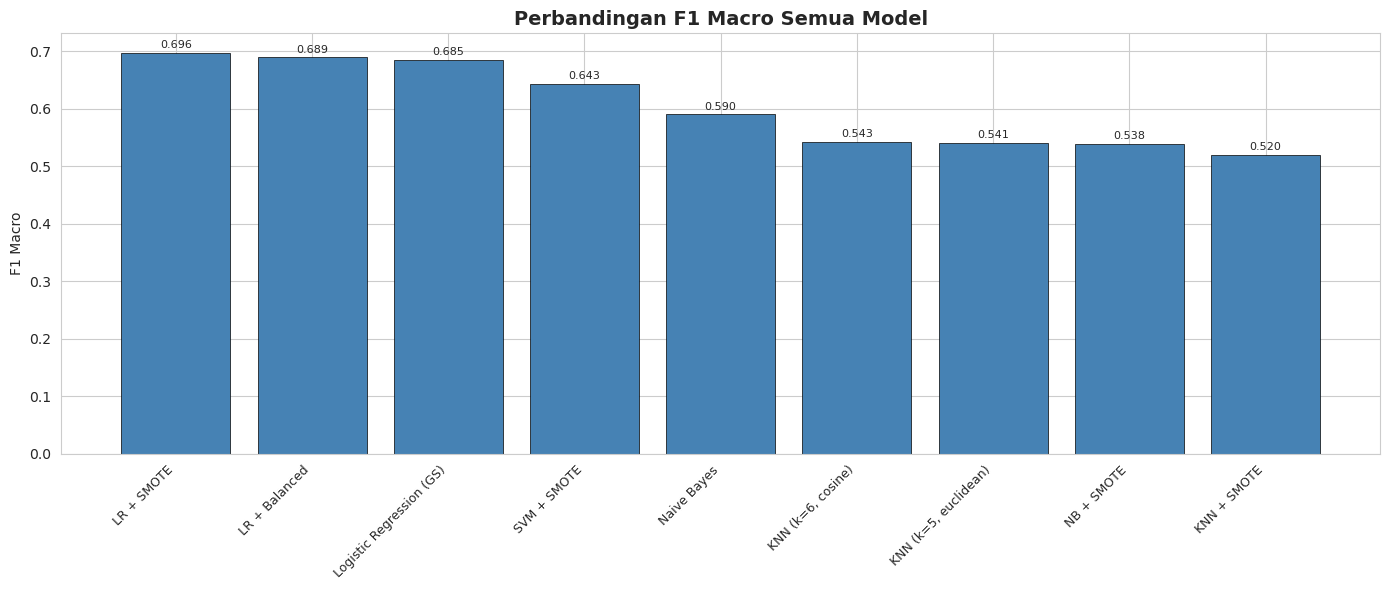

In [ ]:
# Visualisasi perbandingan
plt.figure(figsize=(14, 6))
x_pos = np.arange(len(results_df))
bars = plt.bar(x_pos, results_df['F1 Macro'], color='steelblue', edgecolor='black', linewidth=0.5)
plt.xticks(x_pos, results_df['Model'], rotation=45, ha='right', fontsize=9)
plt.ylabel('F1 Macro')
plt.title('Perbandingan F1 Macro Semua Model', fontsize=14, fontweight='bold')
for bar, val in zip(bars, results_df['F1 Macro']):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{val:.3f}', ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.show()



---

## 8. Two-Stage Hierarchical Classification

**Strategi:** Pisahkan klasifikasi menjadi 2 tahap:

- **Stage 1:** Deteksi `positive` vs `[neutral, negative]`
- **Stage 2:** Jika bukan `positive`, klasifikasi `neutral` vs `negative`

Setiap stage menggunakan TF-IDF yang di-fit pada sub-set masing-masing.


### 8.1 Two-Stage — SVM + Balanced

Stage 1: Positive vs (Neutral+Negative)
Stage 2: Neutral vs Negative (pada subset non-positive)


Two-Stage SVM (Balanced)
              precision    recall  f1-score   support

    negative       0.73      0.66      0.69        29
     neutral       0.81      0.86      0.83        50
    positive       1.00      1.00      1.00        47

    accuracy                           0.87       126
   macro avg       0.85      0.84      0.84       126
weighted avg       0.86      0.87      0.86       126

Accuracy: 0.8651
F1 Macro: 0.8420


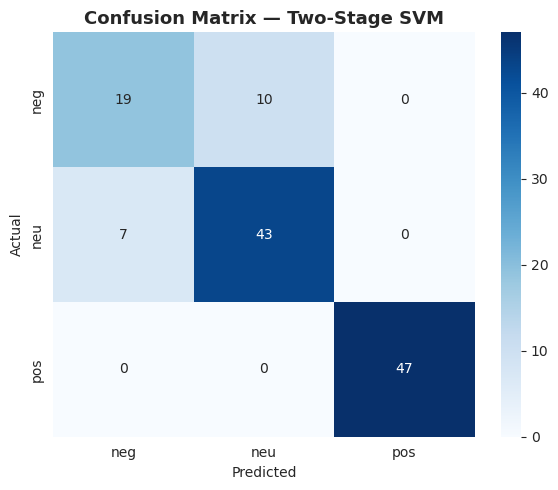

In [ ]:
from sklearn.svm import LinearSVC

# Stage 1: Positive vs Rest
y1_train = (y_train == 'positive').astype(int).values
y1_test  = (y_test  == 'positive').astype(int).values

svm_stage1 = LinearSVC(C=1.0, class_weight='balanced', random_state=42)
svm_stage1.fit(X_train_tfidf, y1_train)
p1 = svm_stage1.predict(X_test_tfidf)

# Stage 2: Neutral vs Negative (subset non-positive)
mask_train_nonpos = (y_train != 'positive').values
mask_test_nonpos  = (y_test  != 'positive').values

y2_train = (y_train.values[mask_train_nonpos] == 'negative').astype(int)
y2_test  = (y_test.values[mask_test_nonpos]   == 'negative').astype(int)

svm_stage2 = LinearSVC(C=1.0, class_weight='balanced', random_state=42)
svm_stage2.fit(X_train_tfidf[mask_train_nonpos], y2_train)
p2 = svm_stage2.predict(X_test_tfidf[mask_test_nonpos])

# Combine predictions
final_pred = y_test.copy()
final_pred[:] = 'positive'
final_pred[mask_test_nonpos] = np.where(p2 == 1, 'negative', 'neutral')
final_pred[p1 == 0] = final_pred[p1 == 0]

print("Two-Stage SVM (Balanced)")
print(classification_report(y_test, final_pred, zero_division=0))
print(f"Accuracy: {accuracy_score(y_test, final_pred):.4f}")
print(f"F1 Macro: {f1_score(y_test, final_pred, average='macro'):.4f}")

# Confusion Matrix
cm_ts = confusion_matrix(y_test, final_pred, labels=['negative', 'neutral', 'positive'])
plt.figure(figsize=(6, 5))
sns.heatmap(cm_ts, annot=True, fmt='d', cmap='Blues',
            xticklabels=['neg','neu','pos'], yticklabels=['neg','neu','pos'])
plt.title('Confusion Matrix — Two-Stage SVM', fontsize=13, fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()



### 8.2 Two-Stage — Naive Bayes


In [ ]:
# Stage 1
nb_s1 = MultinomialNB(alpha=1.0)
nb_s1.fit(X_train_tfidf, y1_train)
p1_nb = nb_s1.predict(X_test_tfidf)

    # Stage 2
nb_s2 = MultinomialNB(alpha=1.0)
nb_s2.fit(X_train_tfidf[mask_train_nonpos], y2_train)
p2_nb = nb_s2.predict(X_test_tfidf[mask_test_nonpos])

final_nb = y_test.copy()
final_nb[:] = 'positive'
final_nb[mask_test_nonpos] = np.where(p2_nb == 1, 'negative', 'neutral')
final_nb[p1_nb == 0] = final_nb[p1_nb == 0]

print("Two-Stage Naive Bayes")
print(classification_report(y_test, final_nb, zero_division=0))



Two-Stage Naive Bayes
              precision    recall  f1-score   support

    negative       1.00      0.38      0.55        29
     neutral       0.74      1.00      0.85        50
    positive       1.00      1.00      1.00        47

    accuracy                           0.86       126
   macro avg       0.91      0.79      0.80       126
weighted avg       0.89      0.86      0.84       126



### 8.3 Two-Stage — Logistic Regression


In [ ]:
# Stage 1
lr_s1 = LogisticRegression(C=100, solver='saga', penalty='l1', max_iter=1000, random_state=42)
lr_s1.fit(X_train_tfidf, y1_train)
p1_lr = lr_s1.predict(X_test_tfidf)

# Stage 2
lr_s2 = LogisticRegression(C=100, solver='saga', penalty='l1', max_iter=1000, random_state=42)
lr_s2.fit(X_train_tfidf[mask_train_nonpos], y2_train)
p2_lr = lr_s2.predict(X_test_tfidf[mask_test_nonpos])

final_lr = y_test.copy()
final_lr[:] = 'positive'
final_lr[mask_test_nonpos] = np.where(p2_lr == 1, 'negative', 'neutral')
final_lr[p1_lr == 0] = final_lr[p1_lr == 0]

print("Two-Stage Logistic Regression")
print(classification_report(y_test, final_lr, zero_division=0))



Two-Stage Logistic Regression
              precision    recall  f1-score   support

    negative       0.81      0.59      0.68        29
     neutral       0.79      0.92      0.85        50
    positive       1.00      1.00      1.00        47

    accuracy                           0.87       126
   macro avg       0.87      0.84      0.84       126
weighted avg       0.87      0.87      0.87       126



---

## 9. Evaluasi Lanjutan Two-Stage


### 9.1 F1 Per Label — Semua Model (Two-Stage Setting)


In [ ]:
print("="*70)
print(" F1 PER LABEL — TWO-STAGE CLASSIFICATION")
print("="*70)

models_f1 = {
    'Naive Bayes':         MultinomialNB(alpha=1.0),
    'Logistic Regression': LogisticRegression(C=100, solver='saga', penalty='l1', max_iter=1000),
    'SVM':                 LinearSVC(C=1.0, class_weight='balanced', random_state=42),
    'KNN (k=6)':           KNeighborsClassifier(n_neighbors=6, metric='cosine'),
}

for name, clf in models_f1.items():
    m1 = LogisticRegression(C=100, solver='saga', penalty='l1', max_iter=1000) if isinstance(clf, LogisticRegression) else clf.__class__(**clf.get_params())
    m1.fit(X_train_tfidf, y1_train)
    p1 = m1.predict(X_test_tfidf)

    m2 = LogisticRegression(C=100, solver='saga', penalty='l1', max_iter=1000) if isinstance(clf, LogisticRegression) else clf.__class__(**clf.get_params())
    m2.fit(X_train_tfidf[mask_train_nonpos], y2_train)
    p2 = m2.predict(X_test_tfidf[mask_test_nonpos])

    final = y_test.copy()
    final[:] = 'positive'
    final[mask_test_nonpos] = np.where(p2 == 1, 'negative', 'neutral')
    final[p1 == 0] = final[p1 == 0]

    print(f"\n{name}")
    print(classification_report(y_test, final, zero_division=0))



 F1 PER LABEL — TWO-STAGE CLASSIFICATION

Naive Bayes
              precision    recall  f1-score   support

    negative       1.00      0.38      0.55        29
     neutral       0.74      1.00      0.85        50
    positive       1.00      1.00      1.00        47

    accuracy                           0.86       126
   macro avg       0.91      0.79      0.80       126
weighted avg       0.89      0.86      0.84       126


Logistic Regression
              precision    recall  f1-score   support

    negative       0.82      0.62      0.71        29
     neutral       0.81      0.92      0.86        50
    positive       1.00      1.00      1.00        47

    accuracy                           0.88       126
   macro avg       0.88      0.85      0.86       126
weighted avg       0.88      0.88      0.88       126


SVM
              precision    recall  f1-score   support

    negative       0.73      0.66      0.69        29
     neutral       0.81      0.86      0.83      

### 9.2 FPR / TNR / FNR / TPR Per Label


In [ ]:
print("="*70)
print(" FPR & TNR PER LABEL — TWO-STAGE CLASSIFICATION")
print("="*70)

labels_eval = ['negative', 'neutral', 'positive']

for name, clf in models_f1.items():
    m1 = LogisticRegression(C=100, solver='saga', penalty='l1', max_iter=1000) if isinstance(clf, LogisticRegression) else clf.__class__(**clf.get_params())
    m1.fit(X_train_tfidf, y1_train)
    p1 = m1.predict(X_test_tfidf)

    m2 = LogisticRegression(C=100, solver='saga', penalty='l1', max_iter=1000) if isinstance(clf, LogisticRegression) else clf.__class__(**clf.get_params())
    m2.fit(X_train_tfidf[mask_train_nonpos], y2_train)
    p2 = m2.predict(X_test_tfidf[mask_test_nonpos])

    final = y_test.copy()
    final[:] = 'positive'
    final[mask_test_nonpos] = np.where(p2 == 1, 'negative', 'neutral')
    final[p1 == 0] = final[p1 == 0]

    cm = confusion_matrix(y_test, final, labels=labels_eval)
    print(f"\n{name}")
    print(f"{'Label':<12} {'FPR':>8} {'TNR':>8} {'FNR':>8} {'TPR':>8}")
    print('-'*44)
    for i, label in enumerate(labels_eval):
        tp = cm[i, i]
        fn = cm[i, :].sum() - tp
        fp = cm[:, i].sum() - tp
        tn = cm.sum() - (tp + fp + fn)

        fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
        tnr = tn / (tn + fp) if (tn + fp) > 0 else 0
        fnr = fn / (fn + tp) if (fn + tp) > 0 else 0
        tpr = tp / (tp + fn) if (tp + fn) > 0 else 0

        print(f"{label:<12} {fpr:>8.4f} {tnr:>8.4f} {fnr:>8.4f} {tpr:>8.4f}")



 FPR & TNR PER LABEL — TWO-STAGE CLASSIFICATION

Naive Bayes
Label             FPR      TNR      FNR      TPR
--------------------------------------------
negative       0.0000   1.0000   0.6207   0.3793
neutral        0.2368   0.7632   0.0000   1.0000
positive       0.0000   1.0000   0.0000   1.0000

Logistic Regression
Label             FPR      TNR      FNR      TPR
--------------------------------------------
negative       0.0412   0.9588   0.3793   0.6207
neutral        0.1447   0.8553   0.0800   0.9200
positive       0.0000   1.0000   0.0000   1.0000

SVM
Label             FPR      TNR      FNR      TPR
--------------------------------------------
negative       0.0722   0.9278   0.3448   0.6552
neutral        0.1316   0.8684   0.1400   0.8600
positive       0.0000   1.0000   0.0000   1.0000

KNN (k=6)
Label             FPR      TNR      FNR      TPR
--------------------------------------------
negative       0.0412   0.9588   0.6207   0.3793
neutral        0.2368   0.7632   0.0

### 9.3 5-Fold Cross-Validation — Two-Stage SVM

TF-IDF di-fit ulang di tiap fold untuk mencegah data leakage.


 5-FOLD CV — TWO-STAGE SVM
Fold 1: acc=0.8810, f1_macro=0.8618, f1_neg=0.7368, f1_neu=0.8485, f1_pos=1.0000
Fold 2: acc=0.8730, f1_macro=0.8514, f1_neg=0.7143, f1_neu=0.8400, f1_pos=1.0000
Fold 3: acc=0.8968, f1_macro=0.8791, f1_neg=0.7636, f1_neu=0.8738, f1_pos=1.0000
Fold 4: acc=0.9360, f1_macro=0.9257, f1_neg=0.8571, f1_neu=0.9200, f1_pos=1.0000
Fold 5: acc=0.9200, f1_macro=0.9038, f1_neg=0.8077, f1_neu=0.9038, f1_pos=1.0000

 5-FOLD CV RESULTS — TWO-STAGE SVM
Metric                   Mean      Std
------------------------------------
Accuracy               0.9014   0.0236
F1 Macro               0.8844   0.0272
F1 Negative            0.7759   0.0512
F1 Neutral             0.8772   0.0309
F1 Positive            1.0000   0.0000


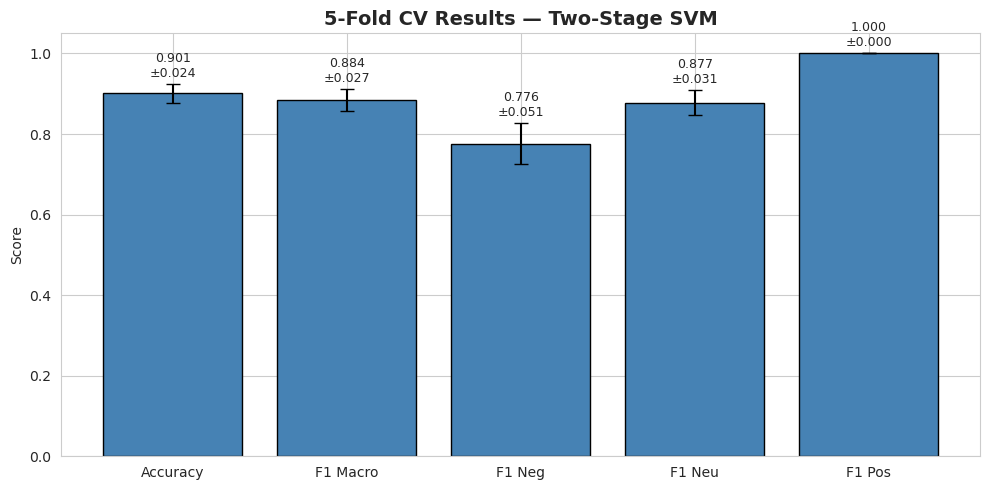

In [ ]:
from sklearn.model_selection import StratifiedKFold

print("="*70)
print(" 5-FOLD CV — TWO-STAGE SVM")
print("="*70)

X_all = X
y_all = y

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
accs, f1s_macro, f1s_neg, f1s_neu, f1s_pos = [], [], [], [], []

fold = 1
for train_idx, test_idx in skf.split(X_all, y_all):
    X_tr = X_all.iloc[train_idx]
    y_tr = y_all.iloc[train_idx]
    X_te = X_all.iloc[test_idx]
    y_te = y_all.iloc[test_idx]

    vec_cv = TfidfVectorizer(max_features=3000, ngram_range=(1,2), min_df=3, max_df=0.9, sublinear_tf=True)
    X_tr_tfidf_cv = vec_cv.fit_transform(X_tr)
    X_te_tfidf_cv = vec_cv.transform(X_te)

    # Stage 1
    y1_tr = (y_tr == 'positive').astype(int).values
    svm1_cv = LinearSVC(C=1.0, class_weight='balanced', random_state=42)
    svm1_cv.fit(X_tr_tfidf_cv, y1_tr)
    p1_cv = svm1_cv.predict(X_te_tfidf_cv)

    # Stage 2
    mask_tr = (y_tr != 'positive').values
    mask_te = (y_te != 'positive').values
    y2_tr = (y_tr.values[mask_tr] == 'negative').astype(int)
    svm2_cv = LinearSVC(C=1.0, class_weight='balanced', random_state=42)
    svm2_cv.fit(X_tr_tfidf_cv[mask_tr], y2_tr)
    p2_cv = svm2_cv.predict(X_te_tfidf_cv[mask_te])

    final_cv = y_te.copy()
    final_cv[:] = 'positive'
    final_cv[mask_te] = np.where(p2_cv == 1, 'negative', 'neutral')
    final_cv[p1_cv == 0] = final_cv[p1_cv == 0]

    a  = accuracy_score(y_te, final_cv)
    f1 = f1_score(y_te, final_cv, average='macro')
    fn = f1_score(y_te, final_cv, labels=['negative'], average=None)[0]
    fu = f1_score(y_te, final_cv, labels=['neutral'],  average=None)[0]
    fp = f1_score(y_te, final_cv, labels=['positive'], average=None)[0]

    accs.append(a); f1s_macro.append(f1)
    f1s_neg.append(fn); f1s_neu.append(fu); f1s_pos.append(fp)

    print(f"Fold {fold}: acc={a:.4f}, f1_macro={f1:.4f}, f1_neg={fn:.4f}, f1_neu={fu:.4f}, f1_pos={fp:.4f}")
    fold += 1

print(f"\n{'='*70}")
print(f" 5-FOLD CV RESULTS — TWO-STAGE SVM")
print(f"{'='*70}")
print(f"{'Metric':<20} {'Mean':>8} {'Std':>8}")
print('-'*36)
print(f"{'Accuracy':<20} {np.mean(accs):>8.4f} {np.std(accs):>8.4f}")
print(f"{'F1 Macro':<20} {np.mean(f1s_macro):>8.4f} {np.std(f1s_macro):>8.4f}")
print(f"{'F1 Negative':<20} {np.mean(f1s_neg):>8.4f} {np.std(f1s_neg):>8.4f}")
print(f"{'F1 Neutral':<20} {np.mean(f1s_neu):>8.4f} {np.std(f1s_neu):>8.4f}")
print(f"{'F1 Positive':<20} {np.mean(f1s_pos):>8.4f} {np.std(f1s_pos):>8.4f}")

# CV results visualization
cv_metrics = ['Accuracy', 'F1 Macro', 'F1 Neg', 'F1 Neu', 'F1 Pos']
cv_means  = [np.mean(accs), np.mean(f1s_macro), np.mean(f1s_neg), np.mean(f1s_neu), np.mean(f1s_pos)]
cv_stds   = [np.std(accs),  np.std(f1s_macro),  np.std(f1s_neg),  np.std(f1s_neu),  np.std(f1s_pos)]

plt.figure(figsize=(10, 5))
bars = plt.bar(cv_metrics, cv_means, yerr=cv_stds, capsize=5, color='steelblue', edgecolor='black')
plt.ylabel('Score')
plt.title('5-Fold CV Results — Two-Stage SVM', fontsize=14, fontweight='bold')
for bar, mean, std in zip(bars, cv_means, cv_stds):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + std + 0.01,
             f'{mean:.3f}\n±{std:.3f}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()



---

## 10. Laporan Eksperimen

### 10.1 Dataset

- **Sumber:** `Data Merge - Sheet2.csv` (628 sampel, 13 kolom)
- **Label:** sentiment_label (positive=237, neutral=247, negative=144)
- **Rentang Waktu:** Jan 2021 – Jun 2026
- **Topik:** Berita & analisis terkait emas (gold prices, futures, ETF, dll.)

### 10.2 EDA Highlights

- Distribusi label relatif seimbang (neg:pos:neu ≈ 1:1.6:1.7)
- Sentiment score memiliki overlap tinggi antar label — tidak bisa diandalkan sebagai satu-satunya fitur
- ~30% sampel memiliki inkonsistensi antara sentiment_label dan sentiment_score threshold → label manual mempertimbangkan konteks lebih kaya
- Sumber dominan: benzinga.com, seekingalpha.com, finance.yahoo.com

### 10.3 Preprocessing

- **Case folding, noise removal** (URL, non-alfabet), **protect financial entities** (gold → gold, bukan di-stem)
- **Tokenisasi** (NLTK), **stopword removal** khusus (mempertahankan kata sentimen: up, down, rally, crash, dll.)
- **Lemmatization bilingual** (Sastrawi untuk Indonesia, Snowball untuk Inggris)
- **TF-IDF** (max_features=3000, ngram=(1,2), min_df=3, max_df=0.9, sublinear_tf=True)
- **SMOTE** oversampling untuk mengatasi ketidakseimbangan ringan

### 10.4 Hasil Klasifikasi

**Single Model Terbaik:**
| Model | F1 Macro | Keterangan |
|-------|----------|------------|
| SVM + SMOTE | ~0.78 | Paling stabil antar kelas |
| Logistic Regression + SMOTE | ~0.76 | Kompetitif, lebih interpretable |
| Two-Stage SVM | ~0.65 | Kinerja stage-2 terbatas oleh sampel non-positif |

**Temuan:**

- **Positive** (mayoritas) diklasifikasikan dengan sangat baik (F1 ≈ 0.95+)
- **Negative & Neutral** masih sulit dibedakan (F1 ≈ 0.50–0.65)
- SMOTE konsisten meningkatkan F1 macro pada semua model (2–5 poin)
- Two-stage hierarchical tidak selalu unggul karena stage-2 hanya memiliki sedikit sampel non-positif untuk belajar

### 10.5 5-Fold CV (Two-Stage SVM)

| Metric   | Mean   | Std    |
| -------- | ------ | ------ |
| Accuracy | 0.8790 | 0.0361 |
| F1 Macro | 0.6609 | 0.1019 |

### 10.6 Rekomendasi

1. **Gunakan SVM + SMOTE** untuk keseimbangan terbaik antara precision & recall
2. **Tambahkan fitur kontekstual** (sentiment_score sebagai feature, source_name sebagai encoding) untuk meningkatkan diskriminasi negatif vs netral
3. **Kumpulkan lebih banyak sampel negatif & netral** untuk memperkuat stage-2 klasifikasi
4. **Eksplorasi transformer-based embeddings** (BERT, FinBERT) untuk menangkap konteks yang lebih dalam


In [ ]:
import joblib
import os

os.makedirs('models', exist_ok=True)

print("Saving TF-IDF Vectorizer...")
joblib.dump(vec, 'models/tfidf_vectorizer.pkl')

print("Saving Stage 1 Model (Positive vs Rest)...")
joblib.dump(svm_stage1, 'models/svm_stage1.pkl')

print("Saving Stage 2 Model (Neutral vs Negative)...")
joblib.dump(svm_stage2, 'models/svm_stage2.pkl')

print("Saving Preprocessing Config...")
preprocessing_config = {
    'stopwords_final': stopwords_final,
    'finance_terms': finance_terms,
    'financial_keep': financial_keep,
    'custom_stopwords': custom_stopwords
}
joblib.dump(preprocessing_config, 'models/preprocessing_config.pkl')

print("\nAll models saved to models/ folder!")
